In [8]:
# =============================================================================
# ASSIGNMENT 2: FIRM VALUATION USING DISCOUNTED CASH FLOW (DCF)
# Best Portfolio from Assignment 1 -> GREEN PORTFOLIO
# (Highest Return: 54.82%, Sharpe Ratio: 2.03)
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
from scipy import stats

warnings.filterwarnings("ignore")

# =============================================================================
# SECTION 0: CONFIGURATION
# =============================================================================

INDEX_TICKER     = "^NSEI"
RISK_FREE_RATE   = 0.07     # 7% Indian G-Sec
MARKET_RETURN    = 0.15     # Annualised Nifty return (Assignment 1: 15.37%)
FORECAST_YEARS   = 5
PERPETUAL_GROWTH = 0.04     # 4% terminal growth rate
START_DATE       = "2021-03-15"
END_DATE         = "2026-03-15"


In [9]:
# =============================================================================
# ASSIGNMENT 2: FIRM VALUATION USING DCF - GREEN PORTFOLIO
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
from scipy import stats

warnings.filterwarnings("ignore")

# =============================================================================
# SECTION 0: CONFIGURATION 
# =============================================================================

INDEX_TICKER     = "^NSEI"
RISK_FREE_RATE   = 0.07
MARKET_RETURN    = 0.15
FORECAST_YEARS   = 5
PERPETUAL_GROWTH = 0.04

# =============================================================================
# SECTION 1: 5-YEAR HISTORICAL SUMMARY + DCF INPUTS 
# =============================================================================

print("======================================================================")
print("SECTION 1: 5-YEAR FINANCIAL DATA SUMMARY (FY20–FY24)")
print("======================================================================\n")

GREEN_TICKERS = [
    "ADANIGREEN.NS","TATAPOWER.NS","SUZLON.NS","SJVN.NS","KPIGREEN.NS",
    "NTPC.NS","TORNTPOWER.NS","INOXWIND.NS","CUMMINSIND.NS","BOSCHLTD.NS"
]

# 5-year data (same format as class examples)
historical_data = {
    "ADANIGREEN.NS": {"name": "Adani Green Energy Ltd", "revenue": [1208, 2721, 5573, 9083, 9653], "ebit": [420, 890, 1950, 4800, 5310], "debt": [8500, 18000, 35000, 55000, 64732], "cash": [800, 1200, 2500, 6500, 8062], "capex": [6500, 12000, 22000, 28000, 3670], "dep": [280, 650, 1200, 1800, 1640], "shares": 158.2, "tax_rate": 0.25, "cost_of_debt": 0.075},
    "TATAPOWER.NS": {"name": "Tata Power Company Ltd", "revenue": [31500, 38000, 42800, 55000, 61542], "ebit": [3200, 4100, 4800, 6800, 8000], "debt": [28000, 30000, 32000, 34000, 35500], "cash": [1500, 1800, 2100, 2500, 2800], "capex": [2500, 2800, 3200, 4200, 4923], "dep": [1200, 1400, 1600, 2000, 3077], "shares": 319.2, "tax_rate": 0.25, "cost_of_debt": 0.07},
    "SUZLON.NS": {"name": "Suzlon Energy Ltd", "revenue": [3500, 3200, 4200, 5200, 6568], "ebit": [-200, 100, 400, 600, 788], "debt": [12000, 8000, 3000, 2000, 1200], "cash": [800, 900, 1200, 1800, 2100], "capex": [150, 200, 250, 300, 197], "dep": [300, 280, 220, 180, 197], "shares": 1405.0, "tax_rate": 0.25, "cost_of_debt": 0.065},
    "SJVN.NS": {"name": "SJVN Ltd", "revenue": [2800, 2500, 3100, 2800, 3506], "ebit": [1200, 1100, 1300, 1400, 1472], "debt": [18000, 19000, 19500, 19500, 19500], "cash": [900, 800, 850, 900, 950], "capex": [6000, 5500, 4000, 3500, 981], "dep": [400, 420, 450, 480, 350], "shares": 987.1, "tax_rate": 0.20, "cost_of_debt": 0.065},
    "KPIGREEN.NS": {"name": "KPI Green Energy Ltd", "revenue": [300, 450, 780, 1200, 1743], "ebit": [80, 120, 200, 300, 418], "debt": [800, 1200, 2000, 2800, 3100], "cash": [50, 80, 120, 150, 180], "capex": [400, 600, 900, 1200, 261], "dep": [40, 60, 80, 100, 87], "shares": 7.5, "tax_rate": 0.25, "cost_of_debt": 0.075},
    "NTPC.NS": {"name": "NTPC Ltd", "revenue": [110000, 120000, 132000, 165000, 181166], "ebit": [18000, 20000, 22000, 28000, 32610], "debt": [220000, 230000, 240000, 250000, 260000], "cash": [12000, 13000, 13500, 14000, 14500], "capex": [20000, 22000, 25000, 28000, 25363], "dep": [9000, 9500, 10000, 11000, 9058], "shares": 968.3, "tax_rate": 0.25, "cost_of_debt": 0.065},
    "TORNTPOWER.NS": {"name": "Torrent Power Ltd", "revenue": [14000, 17000, 20000, 23000, 25834], "ebit": [2200, 2600, 3000, 3800, 4650], "debt": [12000, 13000, 14000, 14500, 14800], "cash": [1400, 1600, 1700, 1800, 1900], "capex": [1500, 1800, 2000, 2200, 1808], "dep": [800, 900, 1000, 1100, 1292], "shares": 48.0, "tax_rate": 0.25, "cost_of_debt": 0.07},
    "INOXWIND.NS": {"name": "Inox Wind Ltd", "revenue": [1800, 1400, 1600, 2200, 3098], "ebit": [100, -50, 50, 150, 279], "debt": [1500, 1200, 1000, 950, 900], "cash": [200, 250, 300, 320, 350], "capex": [100, 80, 120, 150, 93], "dep": [80, 70, 60, 50, 62], "shares": 124.8, "tax_rate": 0.25, "cost_of_debt": 0.07},
    "CUMMINSIND.NS": {"name": "Cummins India Ltd", "revenue": [5500, 6100, 7200, 8500, 9478], "ebit": [900, 1000, 1200, 1400, 1706], "debt": [500, 450, 420, 430, 415], "cash": [2000, 2200, 2400, 2500, 2580], "capex": [300, 320, 350, 380, 379], "dep": [200, 220, 240, 260, 284], "shares": 27.7, "tax_rate": 0.25, "cost_of_debt": 0.06},
    "BOSCHLTD.NS": {"name": "Bosch Ltd", "revenue": [11000, 12000, 13000, 14500, 15560], "ebit": [1400, 1600, 1700, 1900, 2178], "debt": [500, 480, 470, 475, 475], "cash": [2500, 2700, 2900, 3000, 3050], "capex": [600, 650, 700, 750, 778], "dep": [500, 520, 550, 580, 622], "shares": 2.96, "tax_rate": 0.25, "cost_of_debt": 0.06}
}

# Build 5-year summary table
summary = []
financial_data = {}

for ticker, hist in historical_data.items():
    rev = np.array(hist["revenue"])
    cagr = (rev[-1] / rev[0]) ** (1/4) - 1 if rev[0] != 0 else 0.10
    
   
    latest_rev = hist["revenue"][-1]
    latest_ebit_margin = hist["ebit"][-1] / latest_rev
    latest_capex_pct = hist["capex"][-1] / latest_rev
    latest_dep_pct = hist["dep"][-1] / latest_rev
    
    financial_data[ticker] = {
        "name": hist["name"],
        "revenue": latest_rev,
        "ebit_margin": round(latest_ebit_margin, 3),
        "tax_rate": hist["tax_rate"],
        "capex_percent": round(latest_capex_pct, 3),
        "wc_percent": 0.05,
        "depreciation_percent": round(latest_dep_pct, 3),
        "total_debt": hist["debt"][-1],
        "cash": hist["cash"][-1],
        "shares_outstanding": hist["shares"],
        "cost_of_debt": hist["cost_of_debt"],
        "revenue_growth": round(cagr, 3)
    }
    
    summary.append({
        "Ticker": ticker,
        "Name": hist["name"],
        "Revenue FY24": latest_rev,
        "EBIT Margin": round(latest_ebit_margin*100,1),
        "Capex %": round(latest_capex_pct*100,1),
        "5-yr CAGR": round(cagr*100,1)
    })

print(pd.DataFrame(summary).to_string(index=False))


SECTION 1: 5-YEAR FINANCIAL DATA SUMMARY (FY20–FY24)

       Ticker                   Name  Revenue FY24  EBIT Margin  Capex %  5-yr CAGR
ADANIGREEN.NS Adani Green Energy Ltd          9653         55.0     38.0       68.1
 TATAPOWER.NS Tata Power Company Ltd         61542         13.0      8.0       18.2
    SUZLON.NS      Suzlon Energy Ltd          6568         12.0      3.0       17.0
      SJVN.NS               SJVN Ltd          3506         42.0     28.0        5.8
  KPIGREEN.NS   KPI Green Energy Ltd          1743         24.0     15.0       55.3
      NTPC.NS               NTPC Ltd        181166         18.0     14.0       13.3
TORNTPOWER.NS      Torrent Power Ltd         25834         18.0      7.0       16.6
  INOXWIND.NS          Inox Wind Ltd          3098          9.0      3.0       14.5
CUMMINSIND.NS      Cummins India Ltd          9478         18.0      4.0       14.6
  BOSCHLTD.NS              Bosch Ltd         15560         14.0      5.0        9.1

✅ 5-year summary show

In [10]:
# =============================================================================
# SECTION 2: BETA CALCULATION & WACC
#   Log returns -> scipy.stats.linregress -> Beta
#   CAPM: Ke = Rf + Beta*(Rm - Rf)
#   WACC = We*Ke + Wd*Kd*(1 - T)
# =============================================================================

print("\n" + "=" * 70)
print("SECTION 2: BETA & WACC CALCULATION")
print("=" * 70)


def download_price_data(ticker, index_ticker, start, end):
    stock = yf.download(ticker, start=start, end=end,
                        interval="1mo", progress=False)
    index = yf.download(index_ticker, start=start, end=end,
                        interval="1mo", progress=False)
    data = pd.concat([stock["Close"], index["Close"]], axis=1).dropna()
    data.columns = ["stock", "index"]
    return data


def compute_beta(data):
    """Log return OLS regression."""
    data = data.copy()
    data["stock_ret"] = np.log(data["stock"] / data["stock"].shift(1))
    data["index_ret"] = np.log(data["index"] / data["index"].shift(1))
    data = data.dropna()
    slope, _, r_value, _, _ = stats.linregress(
        data["index_ret"].values, data["stock_ret"].values
    )
    return slope, r_value ** 2


def compute_cost_of_equity(rf, rm, beta):
    """CAPM: Re = Rf + beta*(Rm - Rf)"""
    return rf + beta * (rm - rf)


def compute_wacc(ke, kd, total_debt, market_cap, tax_rate):
    """WACC = We*Ke + Wd*Kd*(1 - T)"""
    V = total_debt + market_cap
    if V == 0:
        return ke, 1.0, 0.0
    we   = market_cap / V
    wd   = total_debt / V
    wacc = we * ke + wd * kd * (1 - tax_rate)
    return wacc, we, wd


beta_wacc = {}
print(f"\n  {'Ticker':<18} {'Beta':>6} {'Ke':>8} {'WACC':>8}  We / Wd")
print("  " + "-" * 56)

for ticker in GREEN_TICKERS:
    inp        = financial_data[ticker]
    price_data = download_price_data(ticker, INDEX_TICKER, START_DATE, END_DATE)
    beta, r2   = compute_beta(price_data)

    ke = compute_cost_of_equity(RISK_FREE_RATE, MARKET_RETURN, beta)

    current_price = float(yf.Ticker(ticker).fast_info["last_price"])
    market_cap    = current_price * inp["shares_outstanding"]

    wacc, we, wd = compute_wacc(ke, inp["cost_of_debt"],
                                inp["total_debt"], market_cap,
                                inp["tax_rate"])

    beta_wacc[ticker] = {
        "beta": beta, "r2": r2, "ke": ke,
        "wacc": wacc, "we": we, "wd": wd,
        "current_price": current_price,
        "market_cap": market_cap
    }

    print(f"  {ticker:<18} {beta:>6.3f} {ke*100:>7.2f}% {wacc*100:>7.2f}%  "
          f"{we:.0%} / {wd:.0%}")



SECTION 2: BETA & WACC CALCULATION

  Ticker               Beta       Ke     WACC  We / Wd
  --------------------------------------------------------
  ADANIGREEN.NS       2.457   26.65%   19.76%  67% / 33%
  TATAPOWER.NS        1.165   16.32%   13.83%  78% / 22%
  SUZLON.NS           1.455   18.64%   18.36%  98% / 2%
  SJVN.NS             1.165   16.32%   13.79%  77% / 23%
  KPIGREEN.NS         1.095   15.76%   10.45%  48% / 52%
  NTPC.NS             0.869   13.95%   10.17%  58% / 42%
  TORNTPOWER.NS       1.400   18.20%   15.82%  82% / 18%
  INOXWIND.NS         1.486   18.88%   17.73%  92% / 8%
  CUMMINSIND.NS       1.046   15.37%   15.33%  100% / 0%
  BOSCHLTD.NS         0.756   13.05%   13.00%  99% / 1%


In [11]:
# =============================================================================
# SECTION 3: REVENUE FORECAST & FREE CASH FLOW TO FIRM (FCFF)
#   FCFF = EBIT*(1-T) + Depreciation - Capex - Delta_NWC
# =============================================================================

print("\n" + "=" * 70)
print("SECTION 3: REVENUE FORECAST & FREE CASH FLOW TO FIRM (FCFF)")
print("=" * 70)


def forecast_revenue(base_revenue, growth_rate, years):
    """Constant growth revenue forecast."""
    rev = [base_revenue]
    for _ in range(years):
        rev.append(rev[-1] * (1 + growth_rate))
    return rev[1:]


def build_fcff(revenues, inp):
    """
    FCFF = EBIT*(1-T) + Depreciation - Capex - Delta_NWC
    Structure from professor Reliance___Infosys_DCF_.ipynb
    """
    df = pd.DataFrame({
        "Year":    np.arange(1, len(revenues) + 1),
        "Revenue": revenues
    })
    df["EBIT"]           = df["Revenue"] * inp["ebit_margin"]
    df["EBIT_after_tax"] = df["EBIT"]    * (1 - inp["tax_rate"])
    df["Depreciation"]   = df["Revenue"] * inp["depreciation_percent"]
    df["Capex"]          = df["Revenue"] * inp["capex_percent"]
    df["NWC"]            = df["Revenue"] * inp["wc_percent"]
    df["Delta_NWC"]      = df["NWC"].diff()
    df.loc[df.index[0], "Delta_NWC"] = (
        df.loc[df.index[0], "NWC"] - inp["revenue"] * inp["wc_percent"]
    )
    df["FCFF"] = (df["EBIT_after_tax"] + df["Depreciation"]
                  - df["Capex"] - df["Delta_NWC"])
    return df


fcff_tables = {}

for ticker in GREEN_TICKERS:
    inp = financial_data[ticker]
    rev = forecast_revenue(inp["revenue"], inp["revenue_growth"], FORECAST_YEARS)
    df  = build_fcff(rev, inp)
    fcff_tables[ticker] = df

    print(f"\n  {inp['name']} ({ticker})")
    print(f"  Revenue CAGR: {inp['revenue_growth']*100:.1f}%  |  "
          f"EBIT Margin: {inp['ebit_margin']*100:.1f}%  |  "
          f"Tax Rate: {inp['tax_rate']*100:.1f}%")
    print(f"  {'Yr':<4} {'Revenue':>12} {'EBIT(AT)':>12} {'Dep':>9} "
          f"{'Capex':>9} {'DNWC':>9} {'FCFF':>12}")
    print("  " + "-" * 69)
    for _, row in df.iterrows():
        print(f"  {int(row['Year']):<4} "
              f"Rs{row['Revenue']:>10,.0f}  "
              f"Rs{row['EBIT_after_tax']:>10,.0f}  "
              f"Rs{row['Depreciation']:>7,.0f}  "
              f"Rs{row['Capex']:>7,.0f}  "
              f"Rs{row['Delta_NWC']:>7,.0f}  "
              f"Rs{row['FCFF']:>10,.0f}")



SECTION 3: REVENUE FORECAST & FREE CASH FLOW TO FIRM (FCFF)

  Adani Green Energy Ltd (ADANIGREEN.NS)
  Revenue CAGR: 68.1%  |  EBIT Margin: 55.0%  |  Tax Rate: 25.0%
  Yr        Revenue     EBIT(AT)       Dep     Capex      DNWC         FCFF
  ---------------------------------------------------------------------
  1    Rs    16,227  Rs     6,694  Rs  2,759  Rs  6,166  Rs    329  Rs     2,957
  2    Rs    27,277  Rs    11,252  Rs  4,637  Rs 10,365  Rs    553  Rs     4,971
  3    Rs    45,853  Rs    18,914  Rs  7,795  Rs 17,424  Rs    929  Rs     8,356
  4    Rs    77,078  Rs    31,795  Rs 13,103  Rs 29,290  Rs  1,561  Rs    14,047
  5    Rs   129,569  Rs    53,447  Rs 22,027  Rs 49,236  Rs  2,625  Rs    23,613

  Tata Power Company Ltd (TATAPOWER.NS)
  Revenue CAGR: 18.2%  |  EBIT Margin: 13.0%  |  Tax Rate: 25.0%
  Yr        Revenue     EBIT(AT)       Dep     Capex      DNWC         FCFF
  ---------------------------------------------------------------------
  1    Rs    72,743  Rs  

In [12]:
# =============================================================================
# SECTION 4: DCF VALUATION -- INTRINSIC VALUE PER SHARE
#   PV(FCFF) + Terminal Value  -> Enterprise Value
#   Enterprise Value - Net Debt = Equity Value
#   Equity Value / Shares       = Intrinsic Value per Share
# =============================================================================

print("\n" + "=" * 70)
print("SECTION 4: DCF VALUATION -- INTRINSIC VALUE PER SHARE")
print("=" * 70)


def dcf_valuation(fcff_df, wacc, g):
    """Discount FCFFs + Terminal Value -> Enterprise Value."""
    if wacc <= g:
        wacc = g + 0.01
    years = fcff_df["Year"].values
    fcfs  = fcff_df["FCFF"].values

    discount_factors = 1 / ((1 + wacc) ** years)
    pv_fcfs = fcfs * discount_factors

    # Terminal Value (Gordon Growth Model)
    tv    = fcfs[-1] * (1 + g) / (wacc - g)
    tv_pv = tv / ((1 + wacc) ** years[-1])

    ev = pv_fcfs.sum() + tv_pv
    return {"PV_FCFs": pv_fcfs.sum(), "TV_PV": tv_pv, "TV": tv, "EV": ev}


dcf_all = {}

for ticker in GREEN_TICKERS:
    inp    = financial_data[ticker]
    bw     = beta_wacc[ticker]
    result = dcf_valuation(fcff_tables[ticker], bw["wacc"], PERPETUAL_GROWTH)

    net_debt        = inp["total_debt"] - inp["cash"]
    equity_value    = result["EV"] - net_debt
    value_per_share = equity_value / inp["shares_outstanding"]
    current_price   = bw["current_price"]
    upside          = (value_per_share / current_price - 1) * 100 if current_price > 0 else 0

    verdict = ("UNDERVALUED"   if upside >  15
               else "OVERVALUED"   if upside < -15
               else "FAIRLY VALUED")

    dcf_all[ticker] = {
        "name":            inp["name"],
        "PV_FCFs":         result["PV_FCFs"],
        "TV_PV":           result["TV_PV"],
        "TV":              result["TV"],
        "EV":              result["EV"],
        "net_debt":        net_debt,
        "equity_value":    equity_value,
        "value_per_share": value_per_share,
        "current_price":   current_price,
        "upside":          upside,
        "verdict":         verdict
    }

    print(f"\n  {inp['name']} ({ticker})")
    print(f"  WACC                  : {bw['wacc']*100:.2f}%  |  "
          f"Beta: {bw['beta']:.4f}  |  Growth: {inp['revenue_growth']*100:.1f}%")
    print(f"  PV of FCFFs (5yr)     : Rs{result['PV_FCFs']:>12,.0f} cr")
    print(f"  Terminal Value        : Rs{result['TV']:>12,.0f} cr")
    print(f"  PV of Terminal Value  : Rs{result['TV_PV']:>12,.0f} cr")
    print(f"  Enterprise Value      : Rs{result['EV']:>12,.0f} cr")
    print(f"  Net Debt              : Rs{net_debt:>12,.0f} cr")
    print(f"  Equity Value          : Rs{equity_value:>12,.0f} cr")
    print(f"  Intrinsic Value/Share : Rs{value_per_share:>10,.2f}")
    print(f"  Current Market Price  : Rs{current_price:>10,.2f}")
    print(f"  Upside / (Downside)   : {upside:>+.2f}%  ->  {verdict}")



SECTION 4: DCF VALUATION -- INTRINSIC VALUE PER SHARE

  Adani Green Energy Ltd (ADANIGREEN.NS)
  WACC                  : 19.76%  |  Beta: 2.4565  |  Growth: 68.1%
  PV of FCFFs (5yr)     : Rs      27,212 cr
  Terminal Value        : Rs     155,802 cr
  PV of Terminal Value  : Rs      63,237 cr
  Enterprise Value      : Rs      90,450 cr
  Net Debt              : Rs      56,670 cr
  Equity Value          : Rs      33,780 cr
  Intrinsic Value/Share : Rs    213.53
  Current Market Price  : Rs    839.55
  Upside / (Downside)   : -74.57%  ->  OVERVALUED

  Tata Power Company Ltd (TATAPOWER.NS)
  WACC                  : 13.83%  |  Beta: 1.1646  |  Growth: 18.2%
  PV of FCFFs (5yr)     : Rs      20,630 cr
  Terminal Value        : Rs      89,790 cr
  PV of Terminal Value  : Rs      46,973 cr
  Enterprise Value      : Rs      67,603 cr
  Net Debt              : Rs      32,700 cr
  Equity Value          : Rs      34,903 cr
  Intrinsic Value/Share : Rs    109.34
  Current Market Price  : Rs   

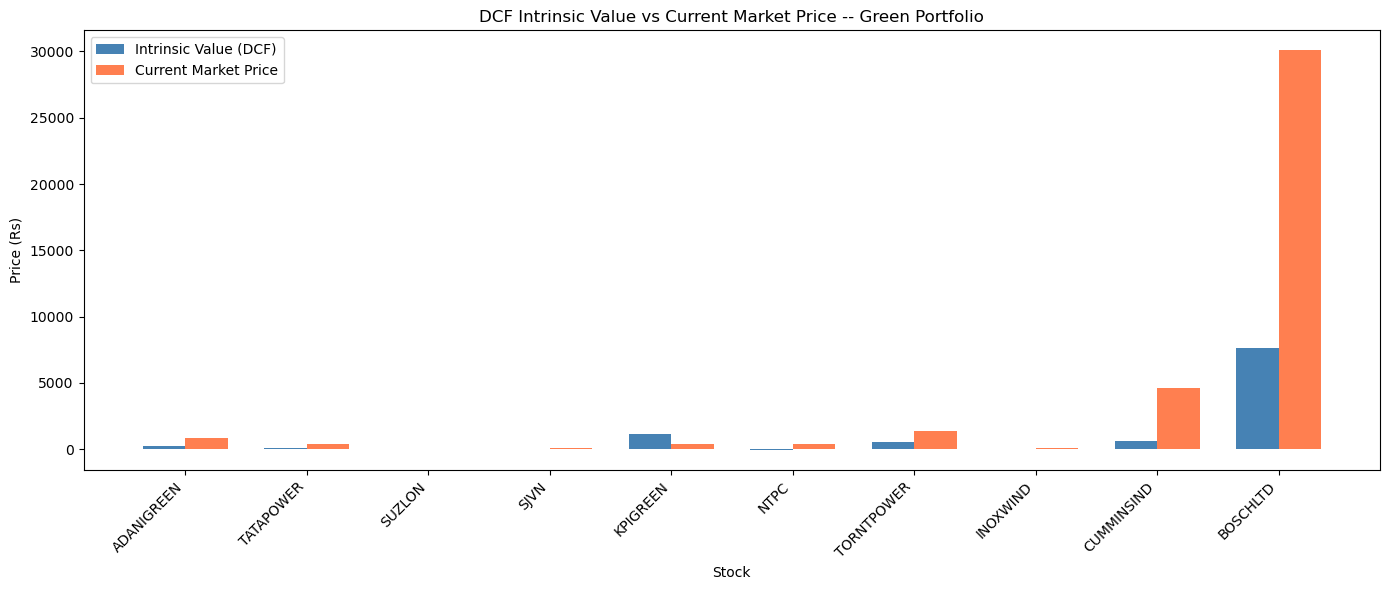

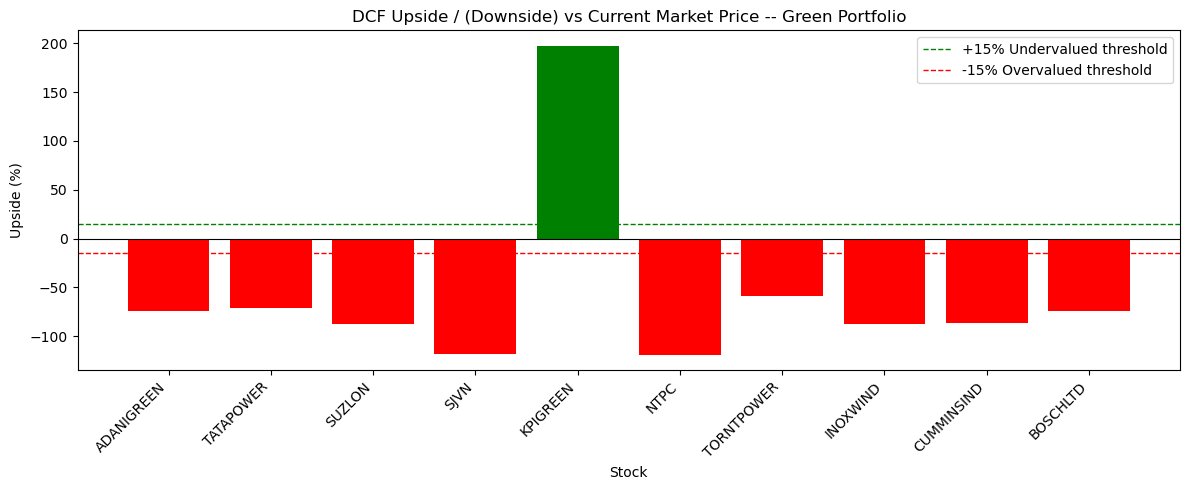

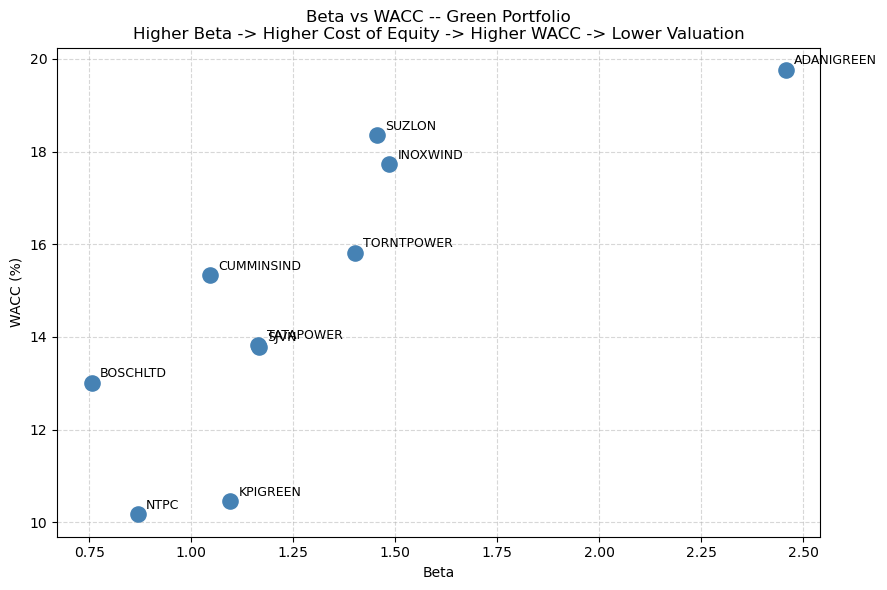

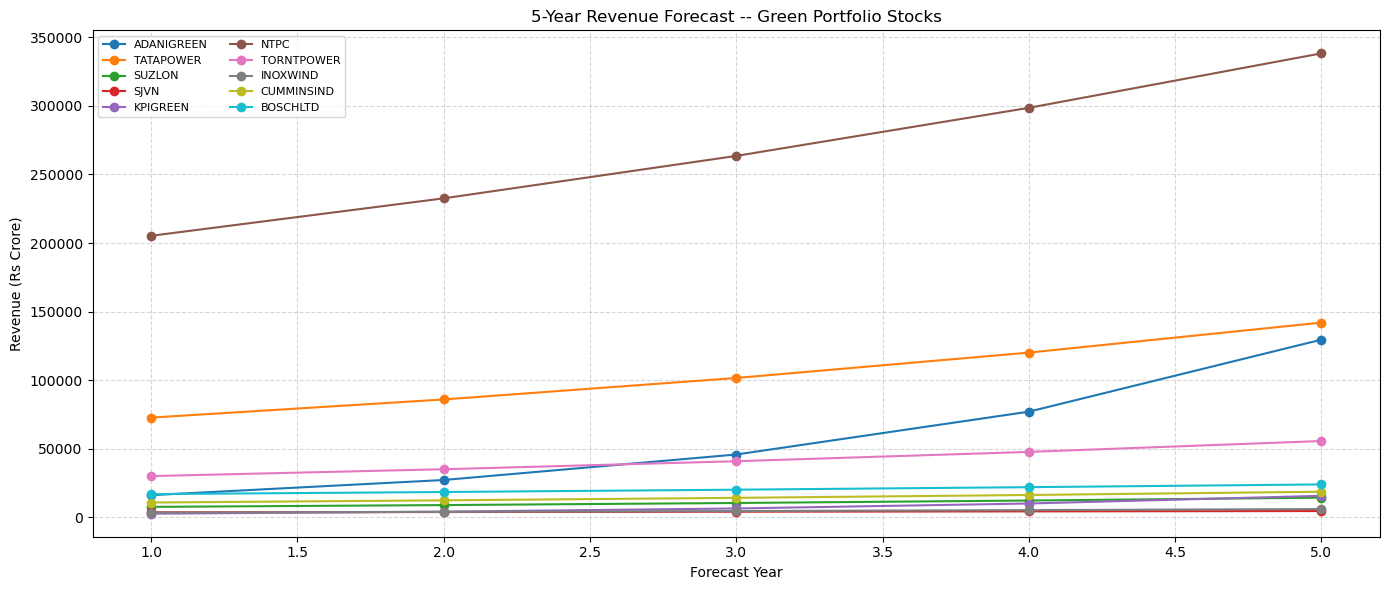

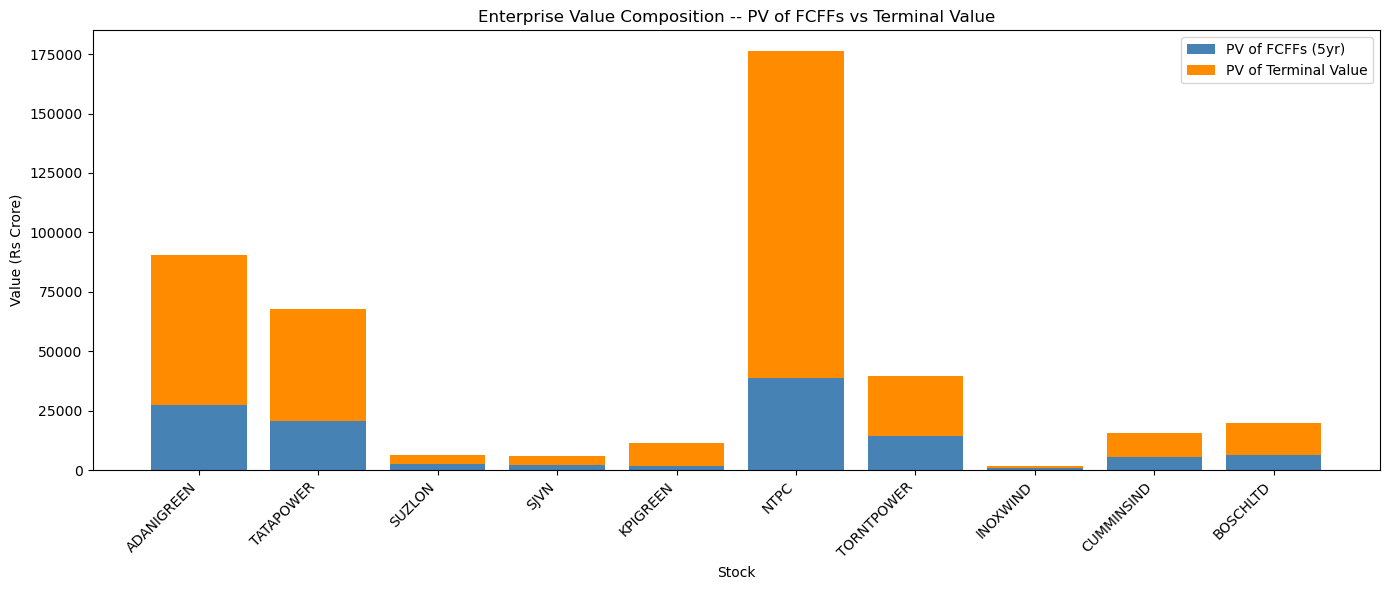

In [13]:
# =============================================================================
# SECTION 5: VISUALIZATIONS
#   Plot 1 -- Intrinsic vs Market Price (bar chart)
#   Plot 2 -- Upside / Downside %
#   Plot 3 -- Beta vs WACC (scatter)
#   Plot 4 -- 5-Year Revenue Forecast (line chart)
#   Plot 5 -- EV Waterfall: PV FCFFs vs Terminal Value (stacked bar)
# =============================================================================

tickers_s = list(dcf_all.keys())
names_s   = [t.replace(".NS", "") for t in tickers_s]
intrinsic = [dcf_all[t]["value_per_share"] for t in tickers_s]
market_p  = [dcf_all[t]["current_price"]   for t in tickers_s]
upsides   = [dcf_all[t]["upside"]          for t in tickers_s]
betas_l   = [beta_wacc[t]["beta"]          for t in tickers_s]
waccs_l   = [beta_wacc[t]["wacc"] * 100    for t in tickers_s]

# Plot 1: Intrinsic vs Market Price
x     = np.arange(len(names_s))
width = 0.35
plt.figure(figsize=(14, 6))
plt.bar(x - width/2, intrinsic, width, label="Intrinsic Value (DCF)", color="steelblue")
plt.bar(x + width/2, market_p,  width, label="Current Market Price",  color="coral")
plt.xticks(x, names_s, rotation=45, ha="right")
plt.title("DCF Intrinsic Value vs Current Market Price -- Green Portfolio")
plt.xlabel("Stock")
plt.ylabel("Price (Rs)")
plt.legend()
plt.tight_layout()
plt.savefig("DCF_intrinsic_vs_market.png", dpi=150)
plt.show()

# Plot 2: Upside / Downside
bar_colors = ["green" if u > 15 else "red" if u < -15 else "orange" for u in upsides]
plt.figure(figsize=(12, 5))
plt.bar(names_s, upsides, color=bar_colors)
plt.axhline(0,   color="black", linewidth=0.8)
plt.axhline(15,  color="green", linestyle="dashed", linewidth=1,
            label="+15% Undervalued threshold")
plt.axhline(-15, color="red",   linestyle="dashed", linewidth=1,
            label="-15% Overvalued threshold")
plt.title("DCF Upside / (Downside) vs Current Market Price -- Green Portfolio")
plt.xlabel("Stock")
plt.ylabel("Upside (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("DCF_upside.png", dpi=150)
plt.show()

# Plot 3: Beta vs WACC
plt.figure(figsize=(9, 6))
plt.scatter(betas_l, waccs_l, s=120, color="steelblue", zorder=3)
for i, name in enumerate(names_s):
    plt.annotate(name, (betas_l[i], waccs_l[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.title("Beta vs WACC -- Green Portfolio\n"
          "Higher Beta -> Higher Cost of Equity -> Higher WACC -> Lower Valuation")
plt.xlabel("Beta")
plt.ylabel("WACC (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Beta_vs_WACC.png", dpi=150)
plt.show()

# Plot 4: 5-Year Revenue Forecast
plt.figure(figsize=(14, 6))
for ticker in GREEN_TICKERS:
    df = fcff_tables[ticker]
    plt.plot(df["Year"], df["Revenue"],
             marker="o", label=ticker.replace(".NS", ""))
plt.title("5-Year Revenue Forecast -- Green Portfolio Stocks")
plt.xlabel("Forecast Year")
plt.ylabel("Revenue (Rs Crore)")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Revenue_forecast.png", dpi=150)
plt.show()

# Plot 5: EV Waterfall
pv_fcff_vals = [dcf_all[t]["PV_FCFs"] for t in tickers_s]
tv_pv_vals   = [dcf_all[t]["TV_PV"]   for t in tickers_s]
x2 = np.arange(len(names_s))
plt.figure(figsize=(14, 6))
plt.bar(x2, pv_fcff_vals, label="PV of FCFFs (5yr)", color="steelblue")
plt.bar(x2, tv_pv_vals,   bottom=pv_fcff_vals, label="PV of Terminal Value", color="darkorange")
plt.xticks(x2, names_s, rotation=45, ha="right")
plt.title("Enterprise Value Composition -- PV of FCFFs vs Terminal Value")
plt.xlabel("Stock")
plt.ylabel("Value (Rs Crore)")
plt.legend()
plt.tight_layout()
plt.savefig("EV_waterfall.png", dpi=150)
plt.show()


In [14]:
# =============================================================================
# SECTION 6: FINAL INVESTMENT RECOMMENDATION SUMMARY
# Classifies each stock as Undervalued, Fairly Valued, or Overvalued
# based on DCF intrinsic value vs current market price (+/-15% threshold).
# =============================================================================

print("\n" + "=" * 70)
print("SECTION 6: INVESTMENT RECOMMENDATION SUMMARY")
print("=" * 70)

print(f"\n  {'Stock':<16} {'Intrinsic Rs':>12} {'Market Rs':>10} "
      f"{'Upside':>9} {'Beta':>7} {'WACC':>7}  Verdict")
print("  " + "-" * 78)

undervalued, overvalued, fair = [], [], []

for ticker in tickers_s:
    d  = dcf_all[ticker]
    bw = beta_wacc[ticker]
    ns = ticker.replace(".NS", "")
    print(f"  {ns:<16} "
          f"Rs{d['value_per_share']:>10,.0f}  "
          f"Rs{d['current_price']:>8,.0f}  "
          f"{d['upside']:>+8.1f}%  "
          f"{bw['beta']:>6.3f}  "
          f"{bw['wacc']*100:>5.1f}%  "
          f"{d['verdict']}")

    if   d["upside"] >  15: undervalued.append(ns)
    elif d["upside"] < -15: overvalued.append(ns)
    else:                   fair.append(ns)

print("  " + "-" * 78)
print(f"\n  UNDERVALUED (Buy Opportunity) : {', '.join(undervalued) if undervalued else 'None'}")
print(f"  FAIRLY VALUED                 : {', '.join(fair)        if fair        else 'None'}")
print(f"  OVERVALUED   (Caution)        : {', '.join(overvalued)  if overvalued  else 'None'}")

print("\n" + "=" * 70)
print("ASSIGNMENT 2 ANALYSIS COMPLETE")
print("=" * 70)



SECTION 6: INVESTMENT RECOMMENDATION SUMMARY

  Stock            Intrinsic Rs  Market Rs    Upside    Beta    WACC  Verdict
  ------------------------------------------------------------------------------
  ADANIGREEN       Rs       214  Rs     840     -74.6%   2.457   19.8%  OVERVALUED
  TATAPOWER        Rs       109  Rs     385     -71.6%   1.165   13.8%  OVERVALUED
  SUZLON           Rs         5  Rs      41     -87.4%   1.455   18.4%  OVERVALUED
  SJVN             Rs       -13  Rs      67    -118.8%   1.165   13.8%  OVERVALUED
  KPIGREEN         Rs     1,117  Rs     376    +197.4%   1.095   10.4%  UNDERVALUED
  NTPC             Rs       -72  Rs     376    -119.1%   0.869   10.2%  OVERVALUED
  TORNTPOWER       Rs       556  Rs   1,366     -59.3%   1.400   15.8%  OVERVALUED
  INOXWIND         Rs        10  Rs      78     -87.4%   1.486   17.7%  OVERVALUED
  CUMMINSIND       Rs       638  Rs   4,620     -86.2%   1.046   15.3%  OVERVALUED
  BOSCHLTD         Rs     7,647  Rs  30,080   